# Segmentation (Localization) + Classification Pipeline

This notebook combines two models with a clear separation of roles:

1. **YOLOv8-seg breed model** — used ONLY to *segment/locate* the cattle or buffalo
   in the image (mask + bounding box). Its own breed-class prediction is ignored.
2. **EfficientNet-B2 classifier** (with confidence + entropy rejection) — used to
   actually *identify the breed* from the cropped region found by segmentation.

The final output draws the segmentation mask and bounding box, but labels it with
the **classification model's** predicted breed and confidence, not YOLO's own guess.

In [13]:
import cv2
import numpy as np
import torch
import torch.nn as nn
from torchvision import transforms, models
from PIL import Image
from pathlib import Path
from ultralytics import YOLO
import matplotlib.pyplot as plt

# ==================== CONFIG - EDIT THESE PATHS ====================
CODE_DIR = Path(r"D:\B.Tech\CE-AI\Sem 7\MP\Code work")

# YOLO segmentation model - used ONLY for locating the animal (mask + box)
SEG_MODEL_PATH = Path(r"D:\B.Tech\CE-AI\Sem 7\MP\Code work\Yolo_seg\runs\segment\breed_segmentation\yolov8n_seg_optimized-2\weights\best.pt")

# General-purpose detector used as a gate check (is there even an animal here?)
GATE_CONF_THRESHOLD = 0.30
SEG_CONF_THRESHOLD = 0.35
SEG_IOU_THRESHOLD = 0.45
COW_CLASS_ID = 19   # COCO class id for "cow" in yolov8m.pt

# Classification model checkpoint (breed identification happens here)
EFFNET_CKPT = CODE_DIR / "best_model_v2_effnetb2.pth"

# Image to run the pipeline on
IMAGE_PATH = Path(r"D:\B.Tech\CE-AI\Sem 7\MP\Datasets\Custom_data\clean_images\cattle\deoni\deoni_0002.jpg")   # <-- change this
OUTPUT_PATH = IMAGE_PATH.parent / f"{IMAGE_PATH.stem}_seg_classified{IMAGE_PATH.suffix}"

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]


Using device: cuda


In [14]:
# ==================== LOAD MODELS ====================

# 1. Gate detector - general object detector, just confirms "is there an animal here?"
gate_detector = YOLO("yolov8m.pt")

# 2. Segmentation model - locates the animal (mask + bounding box) - class labels IGNORED
seg_model = YOLO(str(SEG_MODEL_PATH))

# 3. Classification model - this is what actually decides the breed
eff_checkpoint = torch.load(EFFNET_CKPT, map_location=DEVICE)
eff_classes = eff_checkpoint["classes"]
NUM_CLASSES = len(eff_classes)

effnet_model = models.efficientnet_b2(weights=None)
in_features = effnet_model.classifier[1].in_features
effnet_model.classifier[1] = nn.Linear(in_features, NUM_CLASSES)
effnet_model.load_state_dict(eff_checkpoint["model_state_dict"])
effnet_model = effnet_model.to(DEVICE)
effnet_model.eval()

eff_transform = transforms.Compose([
    transforms.Resize((260, 260)),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

print(f"Gate detector loaded (yolov8m).")
print(f"Segmentation model loaded: {SEG_MODEL_PATH.name} (used for localization only)")
print(f"Classification model loaded. Val acc at checkpoint: {eff_checkpoint['val_acc']:.4f}")
print(f"Number of breed classes: {NUM_CLASSES}")


Gate detector loaded (yolov8m).
Segmentation model loaded: best.pt (used for localization only)
Classification model loaded. Val acc at checkpoint: 0.8110
Number of breed classes: 62


In [15]:
# ==================== CLASSIFICATION WITH REJECTION ====================
def predict_with_rejection(model, transform, classes, pil_image, device,
                             confidence_threshold=40.0, entropy_threshold=0.9, top_k=5):
    # Returns (is_known, results, entropy_value)
    # is_known: False if the crop is likely NOT a recognized cattle/buffalo breed
    input_tensor = transform(pil_image).unsqueeze(0).to(device)
    with torch.no_grad():
        outputs = model(input_tensor)
        probs = torch.softmax(outputs, dim=1)[0]

    probs_np = probs.cpu().numpy()
    entropy = -np.sum(probs_np * np.log(probs_np + 1e-12))

    top_probs, top_idxs = torch.topk(probs, top_k)
    results = [(classes[idx.item()], prob.item() * 100) for prob, idx in zip(top_probs, top_idxs)]

    top1_confidence = results[0][1]
    is_known = (top1_confidence >= confidence_threshold) and (entropy <= entropy_threshold)

    return is_known, results, entropy


In [16]:
# ==================== CORE PIPELINE FUNCTION ====================
def process_frame(frame):
    # Step 1: Gate check - confirm an animal-like object is present before running
    #          segmentation, to avoid processing completely unrelated images.
    # Step 2: Segmentation - locate the animal (mask + bounding box). The class
    #          label predicted by this model is IGNORED - only geometry is used.
    # Step 3: Classification - crop each detected region and classify it with the
    #          EfficientNet-B2 model (with confidence + entropy rejection).
    # Step 4: Draw the segmentation mask/box, labeled with the CLASSIFIER's result.

    # ---- Step 1: gate check ----
    gate_results = gate_detector.predict(
        frame, classes=[COW_CLASS_ID], conf=GATE_CONF_THRESHOLD,
        device=0 if DEVICE.type == "cuda" else "cpu", verbose=False
    )[0]

    if gate_results.boxes is None or len(gate_results.boxes) == 0:
        annotated = frame.copy()
        cv2.putText(annotated, "No cattle/buffalo detected", (20, 40),
                    cv2.FONT_HERSHEY_SIMPLEX, 1.0, (0, 0, 255), 2)
        return annotated

    # ---- Step 2: segmentation (localization only) ----
    seg_results = seg_model.predict(
        frame, conf=SEG_CONF_THRESHOLD, iou=SEG_IOU_THRESHOLD,
        device=0 if DEVICE.type == "cuda" else "cpu", verbose=False
    )[0]

    annotated = frame.copy()
    overlay = frame.copy()
    h, w = frame.shape[:2]

    if seg_results.masks is not None:
        for mask_tensor in seg_results.masks.data:
            mask = mask_tensor.cpu().numpy()
            mask_resized = cv2.resize(mask, (w, h))
            mask_bool = mask_resized > 0.5
            overlay[mask_bool] = (60, 180, 75)  # fixed color - class-agnostic
        annotated = cv2.addWeighted(overlay, 0.4, annotated, 0.6, 0)

    if seg_results.boxes is not None:
        for i, box in enumerate(seg_results.boxes):
            x1, y1, x2, y2 = map(int, box.xyxy[0])
            x1c, y1c = max(0, x1), max(0, y1)
            x2c, y2c = min(w, x2), min(h, y2)
            if x2c <= x1c or y2c <= y1c:
                continue

            # ---- Step 3: crop the localized region and classify it ----
            crop_bgr = frame[y1c:y2c, x1c:x2c]
            crop_rgb = cv2.cvtColor(crop_bgr, cv2.COLOR_BGR2RGB)
            crop_pil = Image.fromarray(crop_rgb)

            is_known, results, entropy = predict_with_rejection(
                effnet_model, eff_transform, eff_classes, crop_pil, DEVICE
            )

            if is_known:
                label = f"{results[0][0]} {results[0][1]:.1f}%"
                color = (0, 200, 0)
            else:
                label = f"Unknown (conf {results[0][1]:.1f}%)"
                color = (0, 0, 200)

            # ---- Step 4: draw box + classifier's label ----
            cv2.rectangle(annotated, (x1, y1), (x2, y2), color, 2)
            (text_w, text_h), _ = cv2.getTextSize(label, cv2.FONT_HERSHEY_SIMPLEX, 0.6, 2)
            cv2.rectangle(annotated, (x1, y1 - text_h - 8), (x1 + text_w + 4, y1), color, -1)
            cv2.putText(annotated, label, (x1 + 2, y1 - 5),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 255, 255), 2)

    return annotated


In [17]:
# ==================== IMAGE INFERENCE ====================
def run_on_image(image_path, output_path):
    frame = cv2.imread(str(image_path))
    if frame is None:
        raise ValueError(f"Could not read image: {image_path}")

    annotated = process_frame(frame)
    cv2.imwrite(str(output_path), annotated)
    print(f"Saved annotated image to: {output_path}")
    return annotated

# ==================== VIDEO INFERENCE ====================
def run_on_video(video_path, output_path):
    cap = cv2.VideoCapture(str(video_path))
    if not cap.isOpened():
        raise ValueError(f"Could not open video: {video_path}")

    fps = cap.get(cv2.CAP_PROP_FPS)
    width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

    fourcc = cv2.VideoWriter_fourcc(*"mp4v")
    writer = cv2.VideoWriter(str(output_path), fourcc, fps, (width, height))

    frame_idx = 0
    while True:
        ret, frame = cap.read()
        if not ret:
            break
        annotated = process_frame(frame)
        writer.write(annotated)
        frame_idx += 1
        if frame_idx % 30 == 0:
            print(f"  Processed {frame_idx}/{total_frames} frames...")

    cap.release()
    writer.release()
    print(f"Saved annotated video to: {output_path}")

# ==================== UNIFIED ENTRY POINT ====================
def run_inference(input_path, output_path=None):
    input_path = Path(input_path)
    image_extensions = {".jpg", ".jpeg", ".png", ".bmp"}
    video_extensions = {".mp4", ".avi", ".mov", ".mkv"}

    if output_path is None:
        output_path = input_path.parent / f"{input_path.stem}_seg_classified{input_path.suffix}"
    else:
        output_path = Path(output_path)

    if input_path.suffix.lower() in image_extensions:
        result = run_on_image(input_path, output_path)
    elif input_path.suffix.lower() in video_extensions:
        run_on_video(input_path, output_path)
        result = None
    else:
        raise ValueError(f"Unsupported file type: {input_path.suffix}")

    return output_path, result


Saved annotated image to: D:\B.Tech\CE-AI\Sem 7\MP\Datasets\Custom_data\clean_images\cattle\deoni\deoni_0002_seg_classified.jpg


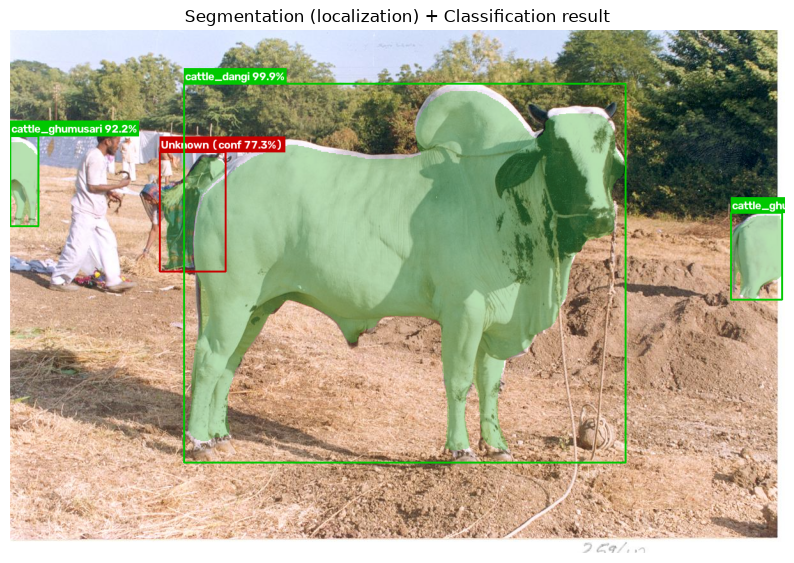

In [18]:
# ==================== RUN + DISPLAY ====================
output_path, annotated = run_inference(IMAGE_PATH)

if annotated is not None:
    annotated_rgb = cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB)
    plt.figure(figsize=(10, 10))
    plt.imshow(annotated_rgb)
    plt.axis("off")
    plt.title("Segmentation (localization) + Classification result")
    plt.show()
